# Employee Performance Analysis and Prediction

This project analyzes employee data to understand the factors affecting employee performance. 
Exploratory data analysis and machine learning techniques are used to identify important factors 
and build a predictive model that can estimate employee performance.

The main objective is to understand how factors such as job satisfaction, work life balance, 
department, and experience influence employee performance and use these insights to support 
better hiring and management decisions.

## Importing Required Libraries

In this step, the required Python libraries are imported. These libraries are used for data 
processing, visualization, and machine learning model building.

- Pandas and NumPy are used for data manipulation.
- Seaborn and Matplotlib are used for data visualization.
- Scikit-learn libraries are used for preprocessing, model training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

## Loading the Dataset

The dataset containing employee information is loaded into a Pandas DataFrame. 
This dataset includes attributes such as department, job satisfaction, work life balance, 
salary hike percentage, and employee performance rating.

The first few rows of the dataset are displayed to understand the structure of the data.

In [3]:
df = pd.read_excel(r"C:\Users\HP\OneDrive\Desktop\Employee_Performance_Project\data\raw\INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xlsx")


df.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


## Basic Data Understanding

Before performing any analysis, it is important to understand the structure of the dataset.

The following steps are performed:
- Checking the shape of the dataset
- Understanding data types of each column
- Viewing column names

In [4]:
df.shape

(1200, 28)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

In [6]:
df.columns

Index(['EmpNumber', 'Age', 'Gender', 'EducationBackground', 'MaritalStatus',
       'EmpDepartment', 'EmpJobRole', 'BusinessTravelFrequency',
       'DistanceFromHome', 'EmpEducationLevel', 'EmpEnvironmentSatisfaction',
       'EmpHourlyRate', 'EmpJobInvolvement', 'EmpJobLevel',
       'EmpJobSatisfaction', 'NumCompaniesWorked', 'OverTime',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'Attrition', 'PerformanceRating'],
      dtype='object')

## Checking Missing Values

Missing values can affect the performance of machine learning models. 
In this step, we check whether any columns contain missing values.

In [7]:
df.isnull().sum()

EmpNumber                       0
Age                             0
Gender                          0
EducationBackground             0
MaritalStatus                   0
EmpDepartment                   0
EmpJobRole                      0
BusinessTravelFrequency         0
DistanceFromHome                0
EmpEducationLevel               0
EmpEnvironmentSatisfaction      0
EmpHourlyRate                   0
EmpJobInvolvement               0
EmpJobLevel                     0
EmpJobSatisfaction              0
NumCompaniesWorked              0
OverTime                        0
EmpLastSalaryHikePercent        0
EmpRelationshipSatisfaction     0
TotalWorkExperienceInYears      0
TrainingTimesLastYear           0
EmpWorkLifeBalance              0
ExperienceYearsAtThisCompany    0
ExperienceYearsInCurrentRole    0
YearsSinceLastPromotion         0
YearsWithCurrManager            0
Attrition                       0
PerformanceRating               0
dtype: int64

## Removing Unnecessary Columns

The column **EmpNumber** represents a unique identifier for each employee. 
Since it does not contribute to predicting employee performance, it is removed from the dataset.

In [8]:
df = df.drop("EmpNumber", axis=1)

## Encoding Categorical Variables

Machine learning algorithms require numerical input. 
Therefore, categorical variables such as department names and job roles are converted into 
numerical form using Label Encoding.

In [9]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

## Saving the Processed Dataset

After preprocessing and encoding the data, the cleaned dataset is saved. 
This processed dataset can be used for future analysis or model training.

In [11]:
df.to_csv(r"C:\Users\HP\OneDrive\Desktop\Employee_Performance_Project\data\processed\processed_employee_data.csv",index=False)

## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand patterns and relationships within the dataset. 
Visualizations help in identifying trends, distributions, and potential factors that influence 
employee performance.

### Work Life Balance Distribution

This visualization shows how employees are distributed across different levels of work life balance.
Understanding this distribution helps in evaluating whether work life balance may influence 
employee productivity and performance.

C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\HP\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


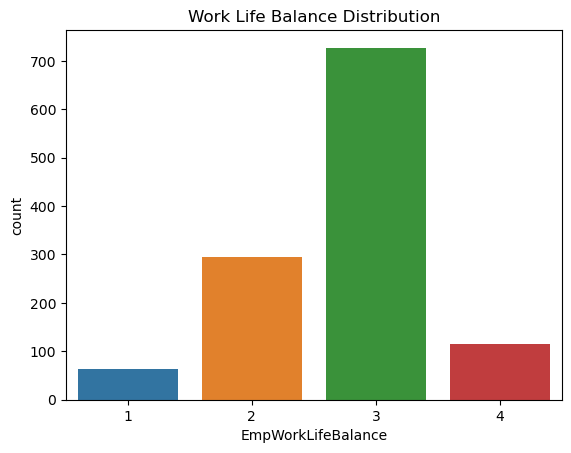

In [12]:
sns.countplot(x="EmpWorkLifeBalance", data=df)
plt.title("Work Life Balance Distribution")
plt.show()

### Department vs Performance Rating

This visualization compares employee performance across different departments. 
It helps identify whether certain departments consistently perform better or worse than others.

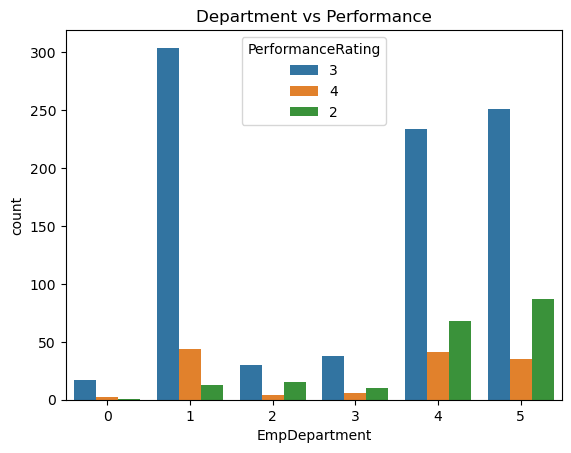

In [14]:
import warnings
warnings.filterwarnings("ignore")

df["PerformanceRating"] = df["PerformanceRating"].astype(str)

sns.countplot(x="EmpDepartment", hue="PerformanceRating", data=df)

plt.title("Department vs Performance")
plt.show()

### Job Satisfaction Distribution

Job satisfaction is an important factor that can influence employee performance. 
This chart shows the distribution of job satisfaction levels among employees.

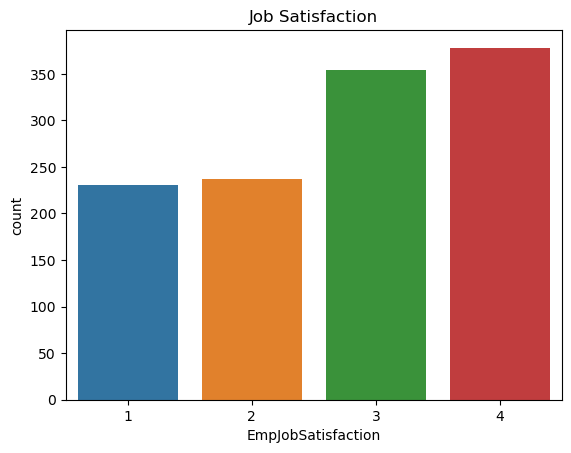

In [15]:
sns.countplot(x="EmpJobSatisfaction", data=df)
plt.title("Job Satisfaction")
plt.show()

### Correlation Heatmap

A correlation heatmap is used to understand relationships between numerical features 
in the dataset. This helps identify which variables are strongly related to employee 
performance and may be important for predictive modeling.

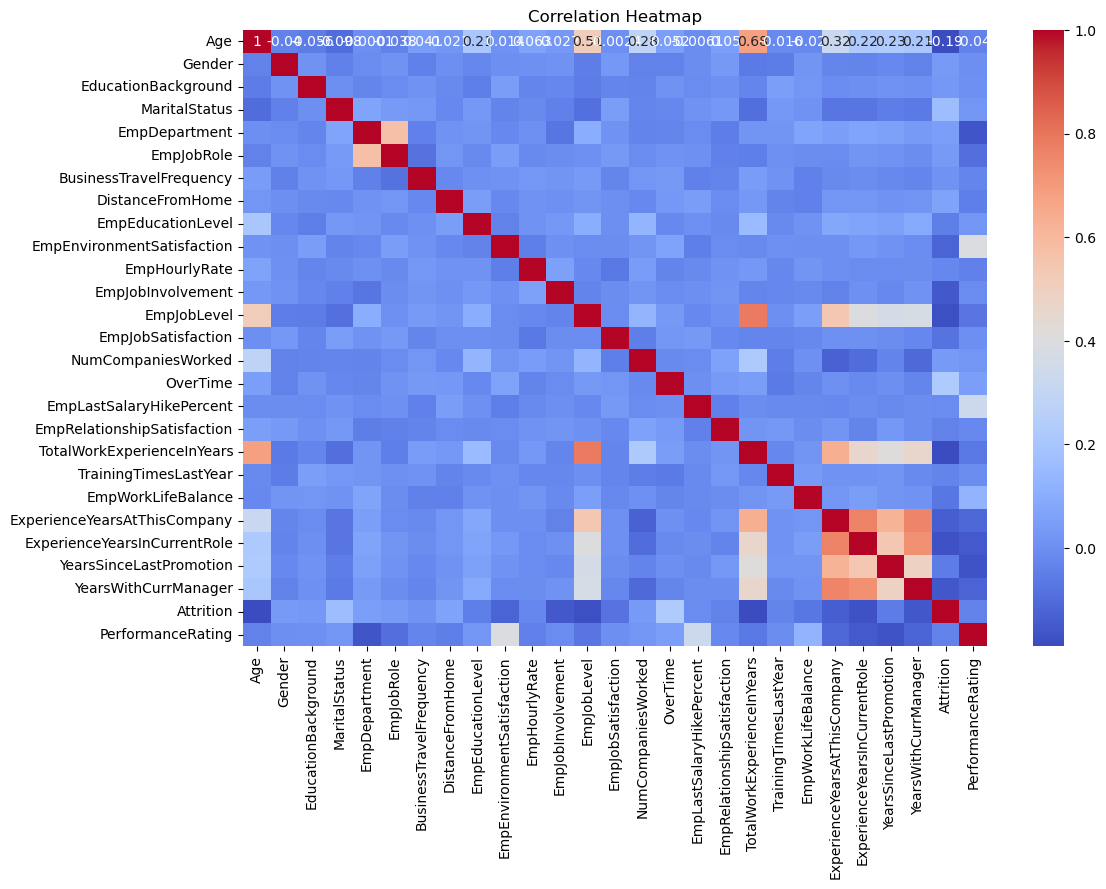

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Feature and Target Variable Split

In this step, the dataset is divided into input features (X) and the target variable (y).

- X contains all the independent variables.
- y contains the employee performance rating which we want to predict.

In [17]:
X = df.drop("PerformanceRating", axis=1)
y = df["PerformanceRating"]

## Train-Test Split

The dataset is split into training and testing sets. 
The training data is used to train the machine learning models, 
while the testing data is used to evaluate the performance of the models.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Feature Scaling

Feature scaling is applied to normalize the data. 
Standardization ensures that all features are on the same scale, 
which improves the performance of some machine learning algorithms.

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Machine Learning Models

### Logistic Regression Model

Logistic Regression is used as the first machine learning algorithm 
to predict employee performance.

In [20]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8458333333333333


### Random Forest Model

Random Forest is an ensemble machine learning algorithm that 
combines multiple decision trees to improve prediction accuracy.

In [21]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9541666666666667


### Support Vector Machine (SVM) Model

Support Vector Machine (SVM) is another machine learning algorithm 
used to classify employee performance based on input features.

In [22]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, y_pred_svm))

SVM Accuracy: 0.8416666666666667


## Model Evaluation

To evaluate model performance, metrics such as classification report 
and confusion matrix are used. These metrics help understand how well 
the model predicts employee performance categories.

### Model Performance Analysis

The classification report shows that the model performs well in predicting employee performance ratings.

The overall model accuracy is **95%**, which indicates that the model correctly predicts most employee performance categories.

For performance rating **3**, the model achieves very high recall (0.99) and F1-score (0.97), indicating excellent prediction for the majority class.

For rating **2**, the model maintains balanced precision and recall (0.93).

For rating **4**, the model achieves perfect precision (1.00), meaning when the model predicts rating 4, it is almost always correct, although recall is slightly lower (0.74).

Overall, the weighted average F1-score of **0.95** shows that the model provides strong and reliable predictions for employee performance.

### Classification Report

In [23]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           2       0.93      0.93      0.93        29
           3       0.95      0.99      0.97       184
           4       1.00      0.74      0.85        27

    accuracy                           0.95       240
   macro avg       0.96      0.89      0.92       240
weighted avg       0.96      0.95      0.95       240



### Confusion Matrix

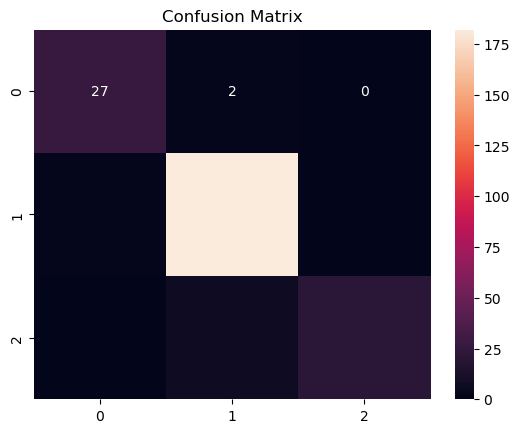

In [24]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

## Feature Importance

Feature importance is calculated using the Random Forest model 
to identify which features have the greatest influence on employee performance.

In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(3))

                       Feature  Importance
16    EmpLastSalaryHikePercent    0.211944
9   EmpEnvironmentSatisfaction    0.208339
23     YearsSinceLastPromotion    0.091361


### Feature Importance Visualization

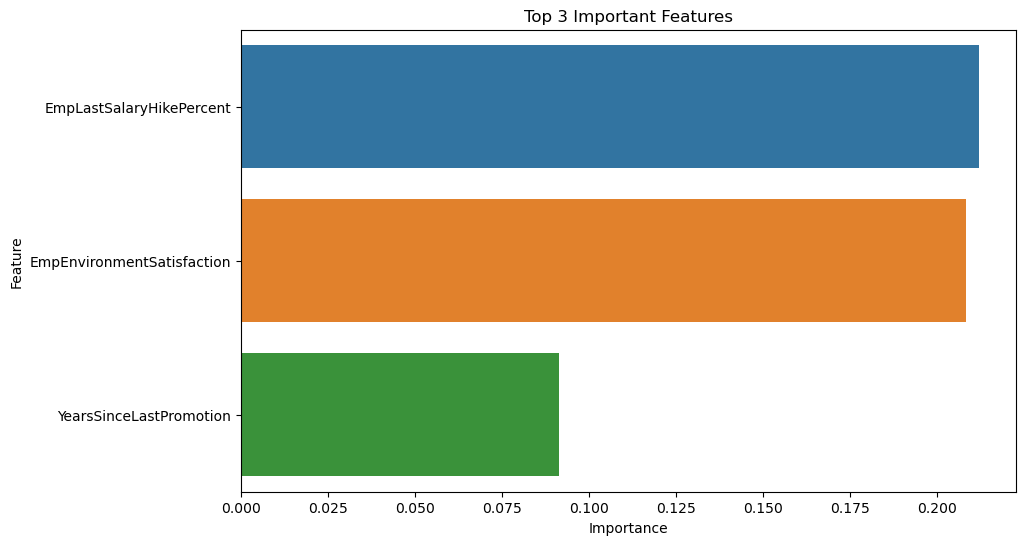

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(3)
)

plt.title("Top 3 Important Features")
plt.show()

## Project Summary

This project focuses on analyzing the factors affecting employee performance and building a machine learning model that can predict the performance rating of employees based on various input features.

Several machine learning algorithms were applied in this project, including **Logistic Regression, Support Vector Machine (SVM), and Random Forest**. These models were trained on the processed dataset and evaluated to determine their prediction accuracy. Among these models, Random Forest provided strong performance and also helped identify the most important factors influencing employee performance.

Feature selection was performed using **feature importance analysis from the Random Forest model**. The most significant features affecting employee performance include factors such as **environment satisfaction, job satisfaction, work life balance, and percentage salary hike**. These features were selected because they showed a stronger relationship with the performance rating and contributed more to prediction accuracy.

Several data preprocessing and analysis techniques were used in this project. These include **data cleaning, label encoding for categorical variables, feature scaling using StandardScaler, correlation analysis, and data visualization using libraries such as Matplotlib and Seaborn**. These techniques helped improve the quality of the data and the performance of the machine learning models.

Overall, the trained model can be used to predict employee performance based on input factors, which can help organizations make better hiring and employee management decisions.


## Methodology

The dataset was first loaded and explored to understand its structure and features. Data preprocessing steps were then applied, including handling categorical variables using **Label Encoding** and performing **feature scaling using StandardScaler** to normalize the data.

The dataset was divided into **training and testing sets** using train-test split to evaluate the performance of the models.

Multiple machine learning algorithms such as **Logistic Regression, Support Vector Machine (SVM), and Random Forest** were trained on the processed dataset. These models were evaluated using performance metrics such as **accuracy, precision, recall, and F1-score**.

Feature importance analysis was also performed to identify the most influential factors affecting employee performance.


## Features Selection / Engineering

### 1. Important Features Selected for Analysis

The most important features affecting employee performance were identified using the **Random Forest feature importance technique**.
This method measures how much each feature contributes to improving the prediction accuracy of the model.

The most influential features include factors such as **environment satisfaction, percentage salary hike, promotion history, job satisfaction, and work life balance**.
These features were considered important because they showed stronger relationships with the employee performance rating and contributed more to the model's predictive power.

### 2. Feature Transformations

Some important feature transformations were applied before training the machine learning models.

Categorical variables such as department names and job roles were converted into numerical values using **Label Encoding**, because machine learning algorithms require numerical input data.

In addition, **feature scaling** was performed using the **StandardScaler** method. This transformation standardizes the feature values so that all variables are on a similar scale, which helps improve the performance of algorithms such as Logistic Regression and Support Vector Machine.

### 3. Correlation and Interaction Among Features

A **correlation heatmap** was used to analyze the relationships among different variables in the dataset.

The heatmap helped identify which features were positively or negatively related to employee performance. Features showing stronger correlations with performance rating were considered more useful for prediction.

This analysis helped in understanding the interaction among variables and supported the selection of relevant features for building the machine learning models.


## Results, Analysis and Insights

### 1. Interesting Relationships in the Data

During the exploratory data analysis, several interesting relationships were observed in the dataset.
Employee performance was found to vary across different departments, indicating that departmental environment and job roles may influence employee productivity.

It was also observed that employees with higher **job satisfaction** and better **work life balance** tend to perform better compared to employees with lower satisfaction levels.
Additionally, factors such as **environment satisfaction and salary hike percentage** showed noticeable influence on employee performance ratings.

### 2. Most Important Technique Used in the Project

The most important technique used in this project is the **Random Forest machine learning algorithm**.
Random Forest not only provides strong predictive performance but also helps identify the most important features affecting employee performance through **feature importance analysis**.

This technique helped in understanding which factors contribute the most to employee performance and supported better decision making.

### 3. Answers to the Business Problem

The main business objective of this project was to analyze the factors affecting employee performance and build a model that can predict performance ratings.

Based on the analysis, it was found that factors such as **job satisfaction, work life balance, environment satisfaction, and salary hike percentage** significantly influence employee performance.

The trained machine learning model achieved high prediction accuracy and can be used by organizations to **predict employee performance during recruitment or employee evaluation processes**.

### 4. Additional Business Insights

From the analysis, several useful business insights were obtained:

* Departments show differences in employee performance levels.
* Employee satisfaction and workplace environment play an important role in improving productivity.
* Fair salary hikes and promotion opportunities can positively impact employee motivation and performance.
* Machine learning models can support data driven hiring and employee management decisions.

These insights can help organizations design better HR strategies to improve employee performance and overall productivity.


## Expected Insights from the Project

The following insights are derived from the analysis of the employee performance dataset:

### 1. Department-wise Performance

The analysis shows that employee performance varies across different departments.
Some departments have a higher number of employees with better performance ratings, while others show comparatively lower performance levels.
This indicates that factors such as work environment, management practices, and job responsibilities may influence employee performance within departments.

### 2. Top 3 Important Factors Affecting Employee Performance

Using **Random Forest feature importance**, the top factors influencing employee performance were identified.
The three most important factors affecting employee performance include:

* EmpLastSalaryHikePercent

* EmpEnvironmentSatisfaction

* YearsSinceLastPromotion

These factors play a significant role in determining how effectively employees perform in their roles.

### 3. Trained Model for Employee Performance Prediction

A machine learning model was developed using algorithms such as **Logistic Regression, Support Vector Machine (SVM), and Random Forest**.
After training and evaluating the models, the trained model can predict **employee performance ratings based on input factors**.

This predictive model can help organizations during the **employee hiring process** by estimating the potential performance of candidates based on relevant attributes.

### 4. Recommendations to Improve Employee Performance

Based on the insights obtained from the analysis, the following recommendations can help improve employee performance:

* Improve **work environment and employee satisfaction levels**.
* Encourage better **work-life balance** for employees.
* Provide **fair salary hikes and growth opportunities** to motivate employees.
* Monitor department-wise performance to identify areas where improvements are needed.

These recommendations can help organizations enhance employee productivity and make better HR decisions.